## Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.

**TF (term frequency):** How common a genre is inside that community — for example, *grunge* shows up a lot in a grunge cluster.

**IDF (inverse document frequency):** How rare that genre is across all communities. Genres that pop up everywhere (like "rock") get down‑weighted, this means that niche genres that concentrate in one community get up‑weighted.

**TF x IDF:** Highlights genres that are both common within one community and uncommon elsewhere — it's the algorithmic nose that tells you *this cluster smells like glam metal, not just generic rock*.


In [12]:
import os, json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

In [13]:
def load_graph_with_genres(path_candidates):
    for p in path_candidates:
        if os.path.exists(p):
            try:
                G = nx.read_graphml(p)
                genres_attr = nx.get_node_attributes(G, "genres")

                if genres_attr:
                    for n, s in genres_attr.items():
                        if isinstance(s, str):
                            genres = [g.strip().lower() for g in s.split(";") if g.strip()]
                            G.nodes[n]["_genres_list"] = genres
                else:
                    base = os.path.splitext(p)[0]
                    json_path = base + "_genres.json"
                    if os.path.exists(json_path):
                        with open(json_path, "r", encoding="utf-8") as f:
                            mapping = json.load(f)
                        for n in G.nodes:
                            genres = mapping.get(n, [])
                            G.nodes[n]["_genres_list"] = [g.strip().lower() for g in genres]
                return G, os.path.basename(p)
            except:
                pass
    return None, None


def compute_communities(G):
    has_attr = "community" in next(iter(G.nodes(data=True)))[1]
    if has_attr:
        communities = defaultdict(list)
        for n, d in G.nodes(data=True):
            communities[d.get("community")].append(n)
        sorted_comms = sorted(communities.items(), key=lambda x: -len(x[1]))
        return [nodes for _, nodes in sorted_comms], "from_node_attribute"

    H = G.to_undirected()
    from networkx.algorithms.community import greedy_modularity_communities
    comms = list(greedy_modularity_communities(H))
    return [list(c) for c in comms], "greedy_modularity"


def build_genre_documents(G, communities):
    docs = []
    for nodes in communities:
        bag = []
        for n in nodes:
            genres = G.nodes[n].get("_genres_list") or []
            bag.extend(genres)
        docs.append(bag)
    return docs


def compute_tfidf(docs):
    N = len(docs)
    vocab = sorted(set(term for doc in docs for term in doc))
    index = {t: i for i, t in enumerate(vocab)}

    tf = np.zeros((N, len(vocab)), dtype=float)
    for d, doc in enumerate(docs):
        counts = Counter(doc)
        total = sum(counts.values())
        for term, c in counts.items():
            tf[d, index[term]] = c / total if total > 0 else 0

    df = np.array([sum(1 for doc in docs if t in doc) for t in vocab])
    idf = np.log((1 + N) / (1 + df)) + 1.0
    tfidf = tf * idf

    return vocab, tfidf, tf, idf, df


def show_heatmap(df_tfidf, top_k=20):
    sums = df_tfidf.sum(axis=0).sort_values(ascending=False)
    keep = sums.head(top_k).index.tolist()
    sub = df_tfidf[keep]

    plt.figure(figsize=(12, 6))
    plt.imshow(sub.values, aspect="auto", cmap="viridis")
    plt.colorbar(label="TF-IDF")
    plt.yticks(range(len(sub.index)), sub.index)
    plt.xticks(range(len(keep)), keep, rotation=45, ha="right")
    plt.title("Top Genres per Community (TF-IDF)")
    plt.show()


def show_top_bars(df_tfidf, top_n=10):
    for comm in df_tfidf.index:
        top = df_tfidf.loc[comm].sort_values(ascending=False).head(top_n)
        plt.figure(figsize=(10, 4))
        plt.bar(top.index, top.values)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Top {top_n} Genres — Community {comm}")
        plt.show()


In [14]:
graph_candidates = ["rock_network_with_genres.graphml"]
G, base_name = load_graph_with_genres(graph_candidates)

if G is None:
    raise FileNotFoundError("⚠️ rock_network_with_genres.graphml not found. Put it next to the notebook.")


In [15]:
communities, method = compute_communities(G)
docs = build_genre_documents(G, communities)
vocab, tfidf, tf, idf, df = compute_tfidf(docs)

comm_labels = list(range(len(communities)))
df_tfidf = pd.DataFrame(tfidf, index=comm_labels, columns=vocab)

✅ TF-IDF complete on: rock_network_with_genres.graphml
Detected 4 communities using greedy_modularity.

🎸 Community 0 (221 artists):
James Taylor, Faces (band), Adam Ant, Eddie Money, Huey Lewis and the News, Thin Lizzy, Ambrosia (band), Manfred Mann (musician), Bo Diddley, Chris Rea, The Everly Brothers, Lenny Kravitz, Grateful Dead, Bee Gees, John Mayall & the Bluesbreakers ...

🎸 Community 1 (170 artists):
Highly Suspect, Nickelback, Buckcherry, Nirvana (band), Seether, Skid Row (American band), Slipknot (band), Stone Sour, FireHouse, Poison (American band), 10 Years (band), Blink-182, Smash Mouth, Nine Inch Nails, Joan Jett ...

🎸 Community 2 (74 artists):
X (American band), Arctic Monkeys, Foals (band), Crash Test Dummies, Cage the Elephant, Interpol (band), Rise Against, Social Distortion, The Cardigans, Green Day, Pixies (band), Sex Pistols, Cake (band), Ben Folds Five, Death Cab for Cutie ...

🎸 Community 3 (19 artists):
38 Special (band), Charlie Daniels, Survivor (band), Jour

,acid rock,acoustic rock,allmusic,alternative metal,alternative metal art rock shoegaze,alternative metal funk metal alternative rock experimental rock,alternative metal funk metal experimental rock progressive rock,alternative metal gothic metal gothic rock hard rock industrial rock symphonic metal nu metal,alternative metal hard rock,alternative metal hard rock nu metal,...,synth pop,texas blues,the daily aztec,the new york times,thrash metal,thrash metal groove metal,western swing,western/cowboy,worldbeat,yacht rock
0,0.010908,0.000000,0.002208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.008181,0.003459,0.000000,0.003459,0.000000,0.000000,0.003459,0.00000,0.003459,0.003459
1,0.000000,0.000000,0.005318,0.026275,0.008332,0.008332,0.008332,0.008332,0.008332,0.008332,...,0.006569,0.000000,0.008332,0.000000,0.016663,0.008332,0.000000,0.00000,0.000000,0.000000
2,0.010715,0.013591,0.008675,0.010715,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.03248,0.000000,0.000000


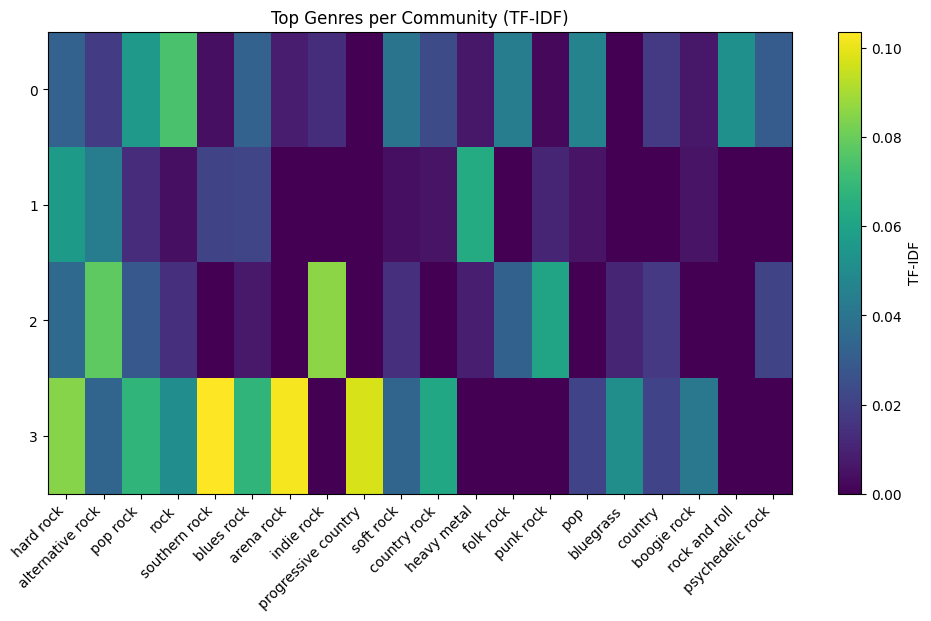

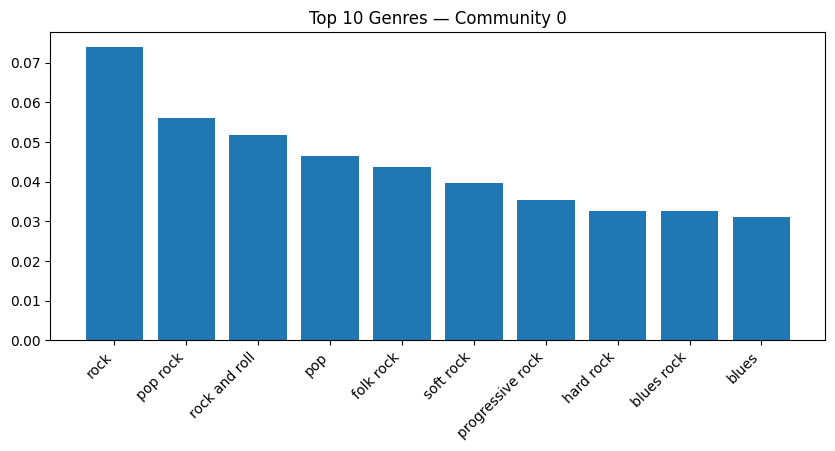

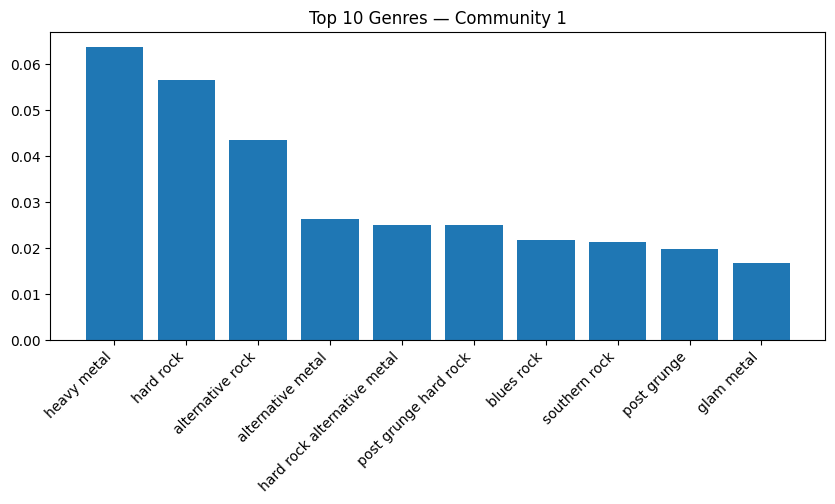

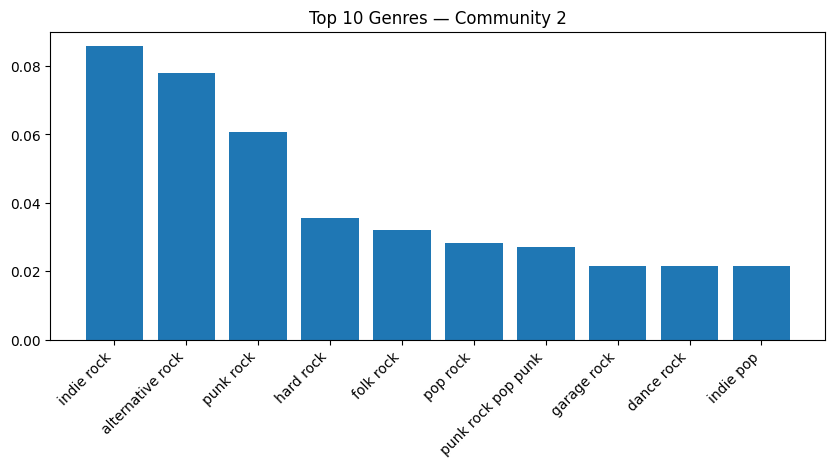

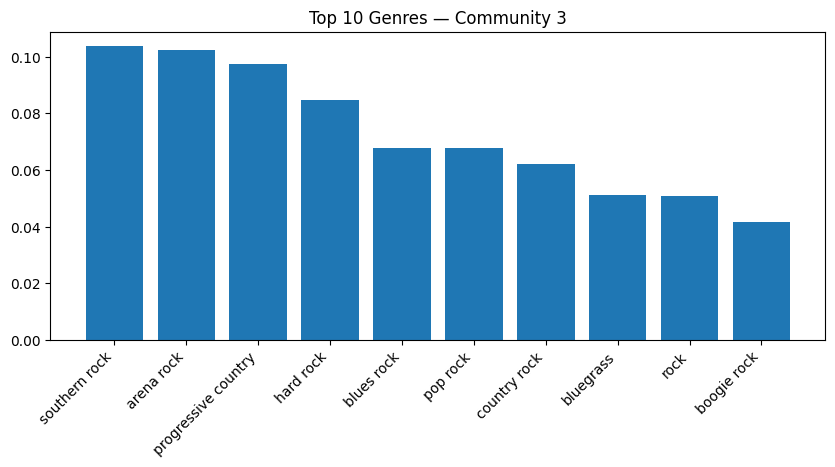

In [16]:
print(f"✅ TF-IDF complete on: {base_name}")
print(f"Detected {len(communities)} communities using {method}.\n")

for i, nodes in enumerate(communities):
    print(f"🎸 Community {i} ({len(nodes)} artists):")
    print(", ".join(nodes[:15]) + (" ..." if len(nodes) > 15 else ""))
    print()

from IPython.display import display
display(df_tfidf.head())

show_heatmap(df_tfidf, top_k=20)
show_top_bars(df_tfidf, top_n=10)

In [20]:
import networkx as nx
import community as louvain  # from python-louvain package

G = nx.read_graphml("rock_network_with_genres.graphml")

# Louvain community detection
partition = louvain.best_partition(G.to_undirected())

# Add as node attribute

for node, comm in partition.items():
    G.nodes[node]["community"] = comm

# Save
nx.write_graphml(G, "rock_network_with_communities.graphml")

print("Saved graph with community labels.")


Found 6 communities via Louvain.
Saved graph with community labels.


In [21]:
import networkx as nx
import pandas as pd
from collections import Counter, defaultdict

# Load enriched graph
G = nx.read_graphml("rock_network_with_communities.graphml")

node_genres = {
    n: [g.strip() for g in str(G.nodes[n].get("genres", "")).split(";") if g.strip()]
    for n in G.nodes()
}

# Community assignment
# Assume each node has a "community" attribute created earlier
node_comms = {n: G.nodes[n].get("community") for n in G.nodes()}

# Count genres overall
genre_counts = Counter([g for genres in node_genres.values() for g in genres])
top_genres = [g for g, _ in genre_counts.most_common(7)]

# Count communities by size
comm_counts = Counter([c for c in node_comms.values() if c is not None])
print("Community sizes:", comm_counts.most_common(7))
top_comms = [c for c, _ in comm_counts.most_common(7)]

print("Top genres:", top_genres)
print("Top communities:", top_comms)

# Build confusion matrix
matrix = pd.DataFrame(
    0, index=top_genres, columns=top_comms, dtype=int
)

for node in G.nodes():
    comm = node_comms[node]
    genres = node_genres[node]

    if comm not in top_comms:
        continue

    # consider all genres for that node
    for g in genres:
        if g in top_genres:
            matrix.loc[g, comm] += 1

print("\nConfusion matrix (genre × community):\n")
print(matrix)

# Normalize by row (optional, to interpret purity of genres by community)
row_norm = matrix.div(matrix.sum(axis=1), axis=0)
print("\nRow-normalized version:\n")
print(row_norm.round(2))


Community sizes: [(4, 131), (5, 123), (3, 96), (0, 75), (2, 55), (1, 4)]
Top genres: ['rock', 'pop rock', 'hard rock', 'alternative rock', 'blues rock', 'soft rock', 'pop']
Top communities: [4, 5, 3, 0, 2, 1]

Confusion matrix (genre × community):

                   4   5   3   0   2  1
rock              29   7   0   2   9  0
pop rock          13  14   1   1  13  0
hard rock          9   6   4  11  11  0
alternative rock   2  18  11   1   1  0
blues rock        10   0   2   3  13  0
soft rock         12   2   0   2  11  0
pop               17   0   1   0   5  0

Row-normalized version:

                     4     5     3     0     2    1
rock              0.62  0.15  0.00  0.04  0.19  0.0
pop rock          0.31  0.33  0.02  0.02  0.31  0.0
hard rock         0.22  0.15  0.10  0.27  0.27  0.0
alternative rock  0.06  0.55  0.33  0.03  0.03  0.0
blues rock        0.36  0.00  0.07  0.11  0.46  0.0
soft rock         0.44  0.07  0.00  0.07  0.41  0.0
pop               0.74  0.00  0.04  0.00 

# Genres vs Communities: Word-Cloud Interpretation

*(Discussion based on the confusion matrix results)*

## Comparing Word-Clouds of Genres and Communities

The confusion matrix reveals how musical genres and network communities overlap, but they do not tell the exact same story. A word-cloud built from genres would emphasize **stylistic labels** directly taken from Wikipedia, while a word-cloud built from community assignments would reflect **structural relationships and collaboration patterns** in the rock ecosystem.

### Genre Word-Cloud

A genre-driven word-cloud highlights explicit musical categories such as:

* **rock**
* **pop rock**
* **hard rock**
* **alternative rock**
* **blues rock**
* **soft rock**
* **pop**

This cloud represents *how artists describe themselves* (or are described historically). It tends to privilege broad, recognizable genre identities. For instance, "rock" dominates simply because it is a large umbrella term that Wikipedia uses for a wide range of artists.

**Interpretation:** The genre word-cloud tells us about cultural labeling — the vocabulary the music world uses to classify sound.

### Community Word-Cloud

A community-driven word-cloud reflects **clusters produced by network structure** such as collaboration links, influence pathways, or co-mentions. Instead of a tidy genre label, these clouds might show:

* Big names that anchor sub-scenes
* Label or era-based clusters (e.g., "Seattle" grunge scene)
* Shared band members, touring networks, label ties

For example, the community heavily aligned with alternative rock produces a cloud likely dominated by influential grunge figures, while the soft-rock/pop cluster produces a cloud dominated by radio-friendly artists with mainstream appeal.

**Interpretation:** Community word-clouds capture *relationships and scenes*, rather than formal tags. They reveal cultural neighborhoods — who worked together, who influenced whom, and who occupied the same artistic circles.

### Key Contrast

Genres are **semantic buckets** — text labels humans assign.

Communities are **structural clusters** — emergent from real-world connections.

When the two word-clouds differ, the message is clear:

> *Genre alone cannot fully explain musical networks — styles blur, scenes overlap, and artists exist in social structures richer than labels can capture.*

Where they align strongly (e.g., the alternative-rock cluster), we see genre as a real social and creative boundary.

Where they diverge (e.g., classic/blues/soft rock blending communities), we see the fluidity and fuzziness of culture.

---

### Bottom Line

The comparison highlights the tension between **how we talk about music** (genres) and **how music communities actually form** (network structure). This reinforces a core insight in cultural network studies:

> Classification systems simplify reality — but the network reveals it.
